# KDD Project — Phase 1: Data Acquisition, Target Construction & Feature Enrichment
## Predicting Optimal Model Routing from Task and Prompt Features

This notebook implements Steps 1–3 of our pipeline:
1. **Load & explore** the LMArena Human Preference 140K dataset
2. **Construct the target variable** (`strong_model_needed`) using Elo ratings
3. **Train a prompt classifier** on WildChat-1M-Tagged, then apply it to Arena data

**Environment:** Google Colab (GPU recommended for Step 3)

---
## 0. Setup & Installs

In [2]:
# Run once — install dependencies
!pip install -q datasets transformers accelerate scikit-learn pandas numpy matplotlib seaborn textstat


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\1whee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Setup complete.")

Setup complete.


---
## Step 1: Load & Explore the Arena 140K Dataset

In [4]:
from datasets import load_dataset

print("Loading Arena Human Preference 140K dataset...")
arena_ds = load_dataset("lmarena-ai/arena-human-preference-140k", split="train")
print(f"Loaded {len(arena_ds):,} rows")
print(f"Columns: {arena_ds.column_names}")

Loading Arena Human Preference 140K dataset...


Loaded 135,634 rows
Columns: ['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp']


In [5]:
# Convert to pandas for easier exploration
# We avoid loading full conversation text into the DataFrame initially to save memory.
# Instead, we extract just the metadata and first user prompt.

print("Converting to DataFrame (metadata + first prompt only)...")

records = []
for i, row in enumerate(arena_ds):
    # Extract the first user message as the "prompt"
    prompt_text = ""
    if row.get("full_conversation") and len(row["full_conversation"]) > 0:
        first_turn = row["full_conversation"][0]
        if isinstance(first_turn, dict) and "content" in first_turn:
            content = first_turn["content"]
            # Content may be a string or a list of content blocks
            if isinstance(content, str):
                prompt_text = content
            elif isinstance(content, list):
                # Extract text from content blocks
                prompt_text = " ".join(
                    block.get("text", "") for block in content
                    if isinstance(block, dict) and block.get("type") == "text"
                )
    
    # Fallback: try conversation_a first user turn
    if not prompt_text and row.get("conversation_a") and len(row["conversation_a"]) > 0:
        first_turn = row["conversation_a"][0]
        if isinstance(first_turn, dict) and "content" in first_turn:
            content = first_turn["content"]
            if isinstance(content, str):
                prompt_text = content
            elif isinstance(content, list):
                prompt_text = " ".join(
                    block.get("text", "") for block in content
                    if isinstance(block, dict) and block.get("type") == "text"
                )
    
    # Extract category tags (stored as a dict of booleans)
    cat_tag = row.get("category_tag", {}) or {}
    
    records.append({
        "id": row.get("id", i),
        "model_a": row.get("model_a", ""),
        "model_b": row.get("model_b", ""),
        "winner": row.get("winner", ""),
        "language": row.get("language", ""),
        "is_code": row.get("is_code", False),
        "prompt_text": prompt_text,
        "num_turns_a": len(row.get("conversation_a", [])) // 2,  # user+assistant pairs
        "num_turns_b": len(row.get("conversation_b", [])) // 2,
        # Unpack category_tag booleans
        "cat_math": cat_tag.get("math", False),
        "cat_coding": cat_tag.get("coding", False),
        "cat_creative_writing": cat_tag.get("creative_writing", False),
        "cat_instruction_following": cat_tag.get("instruction_following", False),
        "cat_hard_prompt": cat_tag.get("hard_prompt", False),
    })
    
    if (i + 1) % 25000 == 0:
        print(f"  Processed {i+1:,} rows...")

df = pd.DataFrame(records)
print(f"\nDataFrame shape: {df.shape}")
df.head(3)

Converting to DataFrame (metadata + first prompt only)...
  Processed 25,000 rows...
  Processed 50,000 rows...
  Processed 75,000 rows...
  Processed 100,000 rows...
  Processed 125,000 rows...

DataFrame shape: (135634, 14)


,id,model_a,model_b,winner,language,is_code,prompt_text,num_turns_a,num_turns_b,cat_math,cat_coding,cat_creative_writing,cat_instruction_following,cat_hard_prompt
0,c4b9710c-8d64-4bee-a0b0-94637ae4cc65,gemini-2.5-pro,claude-3-7-sonnet-20250219-thinking-32k,model_a,en,False,Compare Tormenta20 with DnD5e,1,1,False,False,False,False,False
1,7c44a466-fd07-4992-9764-176b75746a07,claude-3-5-haiku-20241022,claude-3-5-sonnet-20241022,tie,pl,True,"jak w prompcie określić precyzyjnie parametry obrazu do druku, np.wielkość obrazu, powiedzmy 216...",1,1,False,False,False,False,False
2,46e04015-dc69-442a-8b37-3caea0336541,o3-mini,gemma-3n-e4b-it,both_bad,en,True,Solve the following game of Freecell. Cards in later lines are on top of cards in earlier lines....,1,1,False,False,False,False,False


In [6]:
# ---- Structural Audit ----
print("=" * 60)
print("STRUCTURAL AUDIT")
print("=" * 60)

print(f"\n--- Shape: {df.shape[0]:,} rows x {df.shape[1]} columns ---")

print(f"\n--- Winner distribution ---")
print(df['winner'].value_counts())
print(f"\n  Proportions:")
print(df['winner'].value_counts(normalize=True).round(3))

print(f"\n--- Unique models ---")
all_models = set(df['model_a'].unique()) | set(df['model_b'].unique())
print(f"  Total unique models: {len(all_models)}")

print(f"\n--- Top 15 most frequent models ---")
model_counts = pd.concat([df['model_a'], df['model_b']]).value_counts()
print(model_counts.head(15))

print(f"\n--- Language distribution (top 10) ---")
print(df['language'].value_counts().head(10))

print(f"\n--- Category tag frequencies ---")
for col in [c for c in df.columns if c.startswith('cat_')]:
    print(f"  {col}: {df[col].sum():,} ({df[col].mean():.1%})")

print(f"\n--- Missing/empty prompts ---")
empty_prompts = (df['prompt_text'].isna() | (df['prompt_text'].str.strip() == '')).sum()
print(f"  {empty_prompts:,} rows with empty/missing prompts ({empty_prompts/len(df):.1%})")

print(f"\n--- Prompt length stats (word count) ---")
df['prompt_word_count'] = df['prompt_text'].fillna('').str.split().str.len()
print(df['prompt_word_count'].describe().round(1))

STRUCTURAL AUDIT

--- Shape: 135,634 rows x 14 columns ---

--- Winner distribution ---
winner
model_b     49785
model_a     48563
tie         21532
both_bad    15754
Name: count, dtype: int64

  Proportions:
winner
model_b     0.367
model_a     0.358
tie         0.159
both_bad    0.116
Name: proportion, dtype: float64

--- Unique models ---
  Total unique models: 53

--- Top 15 most frequent models ---
claude-opus-4-20250514                     10092
gemini-2.5-flash                            9668
gemini-2.5-pro                              9219
mistral-medium-2505                         9135
qwen3-235b-a22b-no-thinking                 9076
o3-2025-04-16                               8529
claude-sonnet-4-20250514                    8295
chatgpt-4o-latest-20250326                  7650
gemma-3-27b-it                              7326
claude-3-7-sonnet-20250219-thinking-32k     7149
claude-3-7-sonnet-20250219                  6852
command-a-03-2025                           6838
claud

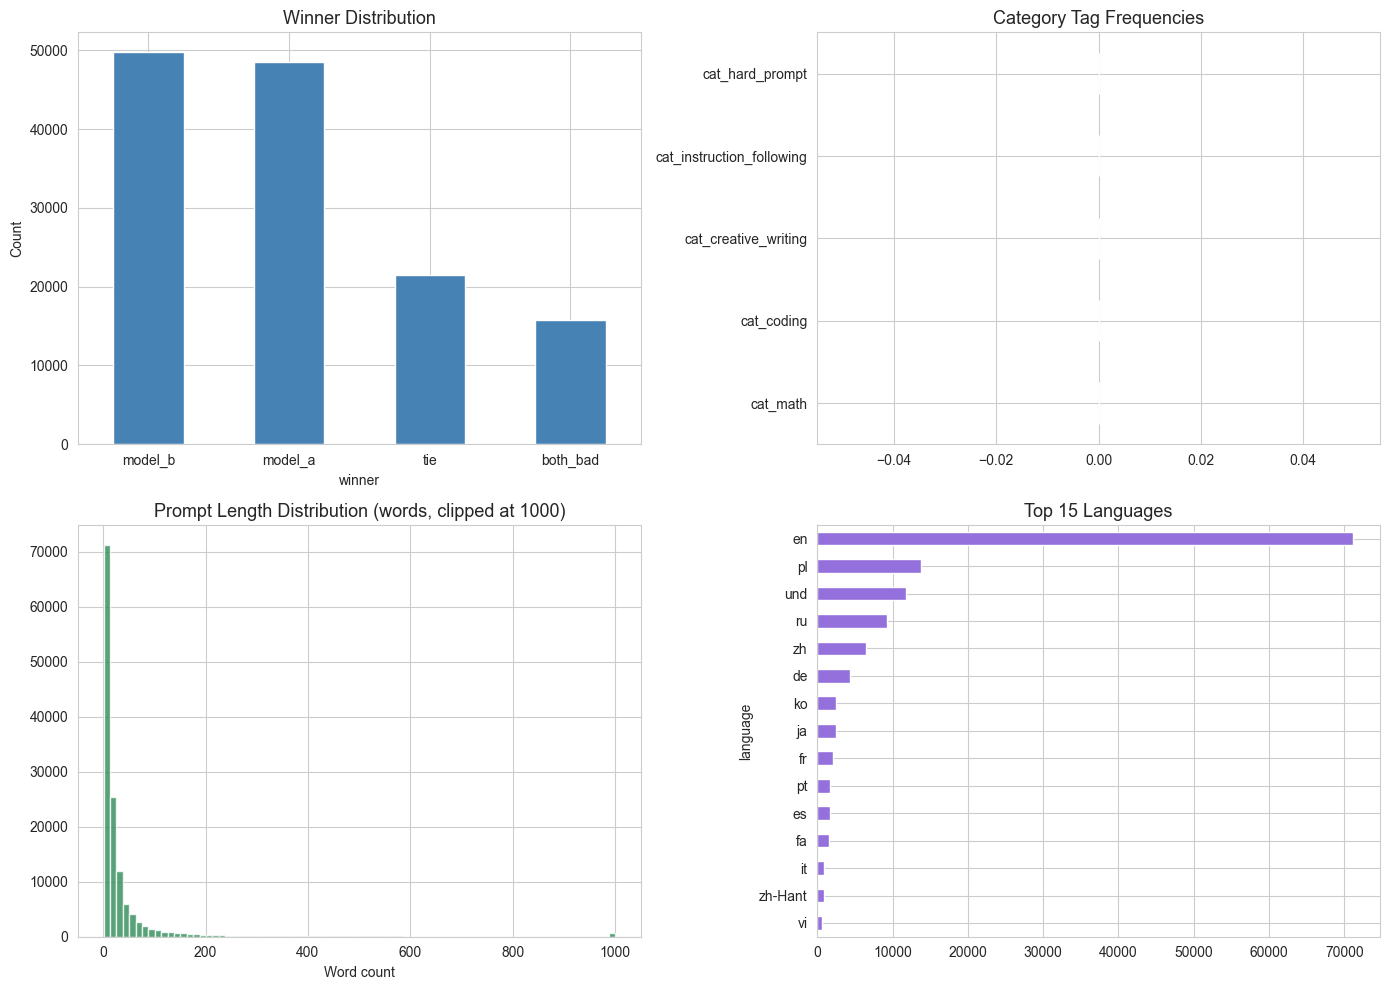

In [7]:
# ---- Visualize key distributions ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Winner distribution
df['winner'].value_counts().plot.bar(ax=axes[0, 0], color='steelblue', edgecolor='white')
axes[0, 0].set_title('Winner Distribution', fontsize=13)
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Category tag co-occurrence
cat_cols = [c for c in df.columns if c.startswith('cat_')]
cat_sums = df[cat_cols].sum().sort_values(ascending=True)
cat_sums.plot.barh(ax=axes[0, 1], color='coral', edgecolor='white')
axes[0, 1].set_title('Category Tag Frequencies', fontsize=13)

# 3. Prompt length distribution (log scale for visibility)
df['prompt_word_count'].clip(upper=1000).hist(
    bins=80, ax=axes[1, 0], color='seagreen', edgecolor='white', alpha=0.8
)
axes[1, 0].set_title('Prompt Length Distribution (words, clipped at 1000)', fontsize=13)
axes[1, 0].set_xlabel('Word count')

# 4. Top 15 languages
df['language'].value_counts().head(15).plot.barh(
    ax=axes[1, 1], color='mediumpurple', edgecolor='white'
)
axes[1, 1].set_title('Top 15 Languages', fontsize=13)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

### Step 1 Findings

**Document your observations here after running the cells above.** Key things to note:
- What's the tie rate? (This affects class balance of the target)
- How many `both_bad` votes are there? (These get excluded)
- Are the category tags sparse or dense? (Affects Tier 1 feature utility)
- Any surprises in the model or language distributions?

---
## Step 2: Construct the Target Variable

We need Elo ratings for each model to determine "stronger" vs "weaker" in each battle.

**Strategy:** We compute Elo ratings directly from the battle outcomes in our dataset using the Bradley-Terry model (same approach used by Chatbot Arena). This is self-contained and reproducible — no external API dependency.

In [8]:
# ---- Assign each battle to a domain bucket for categorical Elo ----
# We use the Arena's own boolean category tags for bucketing.
# A battle can have multiple tags; we use a priority order to pick one bucket.
# Priority: code > math > creative_writing > chat (default)

def assign_domain_bucket(row):
    """Assign a battle to a single domain bucket using priority rules."""
    if row.get('cat_coding', False) or row.get('is_code', False):
        return 'code'
    elif row.get('cat_math', False):
        return 'math_science'
    elif row.get('cat_creative_writing', False):
        return 'creative_writing'
    else:
        return 'chat'

df['domain_bucket'] = df.apply(assign_domain_bucket, axis=1)

print("--- Domain bucket distribution ---")
print(df['domain_bucket'].value_counts())
print(f"\nProportions:")
print(df['domain_bucket'].value_counts(normalize=True).round(3))

--- Domain bucket distribution ---
domain_bucket
chat    96271
code    39363
Name: count, dtype: int64

Proportions:
domain_bucket
chat    0.71
code    0.29
Name: proportion, dtype: float64


In [9]:
# ---- Compute GLOBAL + CATEGORICAL Elo ratings ----
# Global Elo: computed from all battles (same as before)
# Categorical Elo: computed separately within each domain bucket
# Fallback: if a model has < MIN_BATTLES in a category, use global Elo

from collections import defaultdict

MIN_BATTLES_PER_CATEGORY = 50  # Minimum battles to trust a categorical rating

def compute_elo_ratings(battles_df, K=32, initial_rating=1500, num_rounds=5):
    """
    Compute Elo ratings by replaying battles multiple times (bootstrap-style)
    and averaging. This gives more stable ratings than a single pass.
    """
    all_ratings = defaultdict(list)
    
    for round_i in range(num_rounds):
        shuffled = battles_df.sample(frac=1, random_state=round_i).reset_index(drop=True)
        ratings = defaultdict(lambda: initial_rating)
        
        for _, row in shuffled.iterrows():
            a, b = row['model_a'], row['model_b']
            ra, rb = ratings[a], ratings[b]
            
            ea = 1 / (1 + 10 ** ((rb - ra) / 400))
            eb = 1 - ea
            
            if row['winner'] == 'model_a':
                sa, sb = 1.0, 0.0
            elif row['winner'] == 'model_b':
                sa, sb = 0.0, 1.0
            else:
                sa, sb = 0.5, 0.5
            
            ratings[a] += K * (sa - ea)
            ratings[b] += K * (sb - eb)
        
        for model, rating in ratings.items():
            all_ratings[model].append(rating)
    
    return {model: np.mean(scores) for model, scores in all_ratings.items()}


# --- Compute global Elo ---
battles_for_elo = df[df['winner'] != 'tie(bothbad)'].copy()
print(f"Computing GLOBAL Elo from {len(battles_for_elo):,} battles...")
elo_global = compute_elo_ratings(battles_for_elo, K=32, num_rounds=10)

# --- Compute categorical Elo per domain ---
DOMAINS = ['code', 'math_science', 'creative_writing', 'chat']
elo_by_domain = {}
domain_battle_counts = {}  # track model battle counts per domain

for domain in DOMAINS:
    domain_battles = battles_for_elo[battles_for_elo['domain_bucket'] == domain]
    print(f"\nComputing {domain.upper()} Elo from {len(domain_battles):,} battles...")
    
    # Track how many battles each model has in this domain
    model_counts = pd.concat([domain_battles['model_a'], domain_battles['model_b']]).value_counts()
    domain_battle_counts[domain] = model_counts.to_dict()
    
    if len(domain_battles) >= 100:  # Need enough battles for stable ratings
        elo_by_domain[domain] = compute_elo_ratings(domain_battles, K=32, num_rounds=10)
    else:
        print(f"  WARNING: Only {len(domain_battles)} battles — using global Elo as fallback")
        elo_by_domain[domain] = elo_global.copy()

# --- Build a combined Elo lookup with fallback ---
def get_domain_elo(model, domain):
    """Get domain-specific Elo, falling back to global if insufficient data."""
    battle_count = domain_battle_counts.get(domain, {}).get(model, 0)
    if battle_count >= MIN_BATTLES_PER_CATEGORY and domain in elo_by_domain:
        return elo_by_domain[domain].get(model, elo_global.get(model, 1500))
    else:
        return elo_global.get(model, 1500)

# --- Display global rankings ---
elo_df = pd.DataFrame([
    {'model': m, 'elo_global': r} for m, r in elo_global.items()
]).sort_values('elo_global', ascending=False).reset_index(drop=True)

print(f"\nComputed Elo for {len(elo_df)} models.")
print("\n--- Top 20 models by GLOBAL Elo ---")
print(elo_df.head(20).to_string(index=False))

Computing GLOBAL Elo from 135,634 battles...

Computing CODE Elo from 39,363 battles...

Computing MATH_SCIENCE Elo from 0 battles...

Computing CREATIVE_WRITING Elo from 0 battles...

Computing CHAT Elo from 96,271 battles...

Computed Elo for 53 models.

--- Top 20 models by GLOBAL Elo ---
                                       model  elo_global
                              gemini-2.5-pro 1635.473183
                                 grok-4-0709 1604.500009
                        grok-3-preview-02-24 1590.621338
                            deepseek-r1-0528 1589.681140
                gemini-2.5-pro-preview-03-25 1585.300830
                  chatgpt-4o-latest-20250326 1584.788444
                               o3-2025-04-16 1578.619018
                            gemini-2.5-flash 1561.678492
         llama-4-maverick-03-26-experimental 1560.209483
                        kimi-k2-0711-preview 1555.051052
                          o4-mini-2025-04-16 1545.603971
                gemini-

In [10]:
# ---- Compare global vs categorical rankings ----
# This is the key diagnostic: do rankings change across domains?

# Build a comparison table for models with enough data in all domains
comparison_rows = []
for model in elo_global.keys():
    row = {'model': model, 'global': elo_global[model]}
    has_all = True
    for domain in DOMAINS:
        count = domain_battle_counts.get(domain, {}).get(model, 0)
        if count >= MIN_BATTLES_PER_CATEGORY and domain in elo_by_domain:
            row[domain] = elo_by_domain[domain].get(model, np.nan)
            row[f'{domain}_n'] = count
        else:
            row[domain] = np.nan
            row[f'{domain}_n'] = count
            has_all = False
    row['has_all_domains'] = has_all
    comparison_rows.append(row)

elo_compare = pd.DataFrame(comparison_rows)

# Show ranking shifts for models with data in all domains
full_coverage = elo_compare[elo_compare['has_all_domains']].copy()
print(f"Models with >= {MIN_BATTLES_PER_CATEGORY} battles in ALL domains: {len(full_coverage)}")

if len(full_coverage) > 0:
    # Compute rank in each domain
    full_coverage['rank_global'] = full_coverage['global'].rank(ascending=False).astype(int)
    for domain in DOMAINS:
        full_coverage[f'rank_{domain}'] = full_coverage[domain].rank(ascending=False).astype(int)
    
    # Show the models with biggest rank shifts
    rank_cols = ['rank_global'] + [f'rank_{d}' for d in DOMAINS]
    full_coverage['max_rank_shift'] = full_coverage[rank_cols].max(axis=1) - full_coverage[rank_cols].min(axis=1)
    
    display_cols = ['model', 'rank_global', 'rank_code', 'rank_math_science', 'rank_chat', 'max_rank_shift']
    display_cols = [c for c in display_cols if c in full_coverage.columns]
    
    print("\n--- Top 20 models by global rank (with domain ranks) ---")
    print(full_coverage.sort_values('rank_global')[display_cols].head(20).to_string(index=False))
    
    print(f"\n--- Biggest rank shifts (models that change rank the most across domains) ---")
    print(full_coverage.sort_values('max_rank_shift', ascending=False)[display_cols].head(15).to_string(index=False))
    
    # Rank correlation between domains (Kendall's tau)
    from scipy.stats import kendalltau
    print("\n--- Kendall's tau rank correlation between domains ---")
    for i, d1 in enumerate(DOMAINS):
        for d2 in DOMAINS[i+1:]:
            col1, col2 = f'rank_{d1}', f'rank_{d2}'
            if col1 in full_coverage.columns and col2 in full_coverage.columns:
                tau, pval = kendalltau(full_coverage[col1], full_coverage[col2])
                print(f"  {d1} vs {d2}: tau={tau:.3f}, p={pval:.4f}")
else:
    print("Not enough models with full domain coverage. Lowering MIN_BATTLES_PER_CATEGORY may help.")

Models with >= 50 battles in ALL domains: 0
Not enough models with full domain coverage. Lowering MIN_BATTLES_PER_CATEGORY may help.


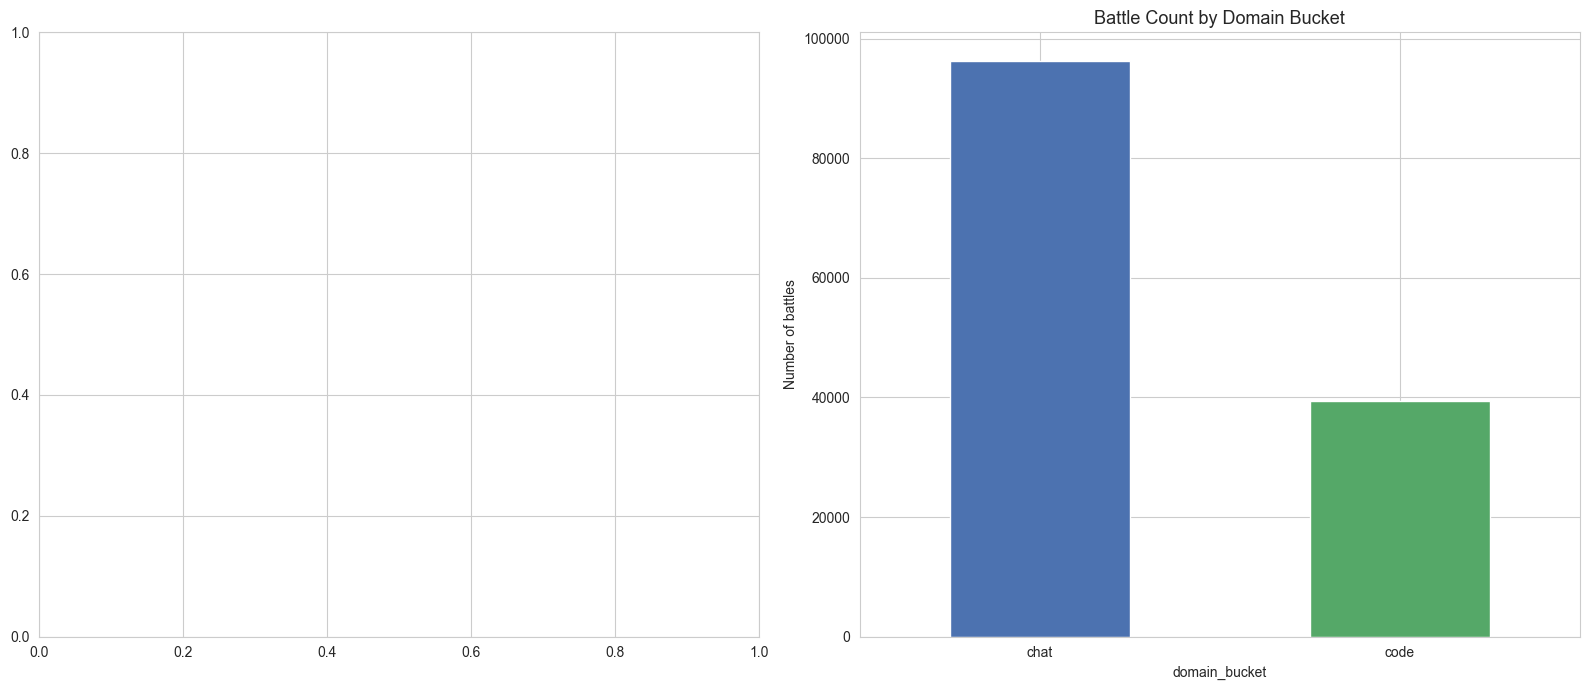

In [11]:
# ---- Visualize domain Elo differences ----

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Heatmap of top models' Elo across domains
if len(full_coverage) >= 5:
    top_models = full_coverage.sort_values('rank_global').head(20)
    heatmap_data = top_models.set_index('model')[DOMAINS + ['global']].copy()
    
    # Normalize each column to show relative standing (z-score within column)
    heatmap_norm = (heatmap_data - heatmap_data.mean()) / heatmap_data.std()
    
    sns.heatmap(
        heatmap_norm, annot=heatmap_data.round(0).astype(int), fmt='d',
        cmap='RdYlGn', center=0, ax=axes[0],
        xticklabels=['Code', 'Math/Sci', 'Creative', 'Chat', 'Global'],
        cbar_kws={'label': 'Relative strength (z-score)'}
    )
    axes[0].set_title('Top 20 Models: Elo by Domain\n(color = relative strength, numbers = raw Elo)', fontsize=11)
    axes[0].set_ylabel('')

# 2. Domain bucket sizes
bucket_counts = df['domain_bucket'].value_counts()
bucket_counts.plot.bar(ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'], edgecolor='white')
axes[1].set_title('Battle Count by Domain Bucket', fontsize=13)
axes[1].set_ylabel('Number of battles')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# ---- Construct the target variable using DOMAIN-SPECIFIC Elo ----
# Key change: "stronger model" is determined by the Elo rating in the
# RELEVANT domain, not the global Elo. This means the "stronger" model
# in a coding battle may differ from the "stronger" model in a chat battle.

df_clean = df[df['winner'] != 'tie(bothbad)'].copy()
print(f"Removed both_bad: {len(df):,} -> {len(df_clean):,} rows")

# Map BOTH global and domain-specific Elo to each battle
df_clean['elo_global_a'] = df_clean['model_a'].map(elo_global)
df_clean['elo_global_b'] = df_clean['model_b'].map(elo_global)
df_clean['elo_global_gap'] = (df_clean['elo_global_a'] - df_clean['elo_global_b']).abs()

# Domain-specific Elo (uses fallback to global if insufficient data)
df_clean['elo_domain_a'] = df_clean.apply(
    lambda r: get_domain_elo(r['model_a'], r['domain_bucket']), axis=1
)
df_clean['elo_domain_b'] = df_clean.apply(
    lambda r: get_domain_elo(r['model_b'], r['domain_bucket']), axis=1
)
df_clean['elo_domain_gap'] = (df_clean['elo_domain_a'] - df_clean['elo_domain_b']).abs()

# Determine stronger model using DOMAIN Elo (primary target)
df_clean['stronger_model_domain'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], 'model_a', 'model_b'
)
df_clean['stronger_model_name'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], df_clean['model_a'], df_clean['model_b']
)
df_clean['weaker_model_name'] = np.where(
    df_clean['elo_domain_a'] >= df_clean['elo_domain_b'], df_clean['model_b'], df_clean['model_a']
)

# PRIMARY target: domain-specific
df_clean['strong_model_won'] = (
    df_clean['winner'] == df_clean['stronger_model_domain']
).astype(int)

# COMPARISON target: what would global Elo say?
df_clean['stronger_model_global'] = np.where(
    df_clean['elo_global_a'] >= df_clean['elo_global_b'], 'model_a', 'model_b'
)
df_clean['strong_model_won_global'] = (
    df_clean['winner'] == df_clean['stronger_model_global']
).astype(int)

# How often do domain and global Elo disagree about who's stronger?
disagree_mask = df_clean['stronger_model_domain'] != df_clean['stronger_model_global']
print(f"\nDomain vs Global Elo DISAGREE on stronger model: "
      f"{disagree_mask.sum():,} / {len(df_clean):,} battles ({disagree_mask.mean():.1%})")
print(f"  (These are battles where categorical Elo changes the target label)")

print(f"\n--- Target distribution (domain Elo) ---")
print(df_clean['strong_model_won'].value_counts(normalize=True).round(3))

print(f"\n--- Target distribution (global Elo, for comparison) ---")
print(df_clean['strong_model_won_global'].value_counts(normalize=True).round(3))

Removed both_bad: 135,634 -> 135,634 rows

Domain vs Global Elo DISAGREE on stronger model: 13,361 / 135,634 battles (9.9%)
  (These are battles where categorical Elo changes the target label)

--- Target distribution (domain Elo) ---
strong_model_won
0    0.544
1    0.456
Name: proportion, dtype: float64

--- Target distribution (global Elo, for comparison) ---
strong_model_won_global
0    0.545
1    0.455
Name: proportion, dtype: float64


Domain Elo gap distribution:
count    135634.0
mean         70.5
std          50.1
min           0.0
25%          30.1
50%          61.8
75%         102.9
max         262.6
Name: elo_domain_gap, dtype: float64


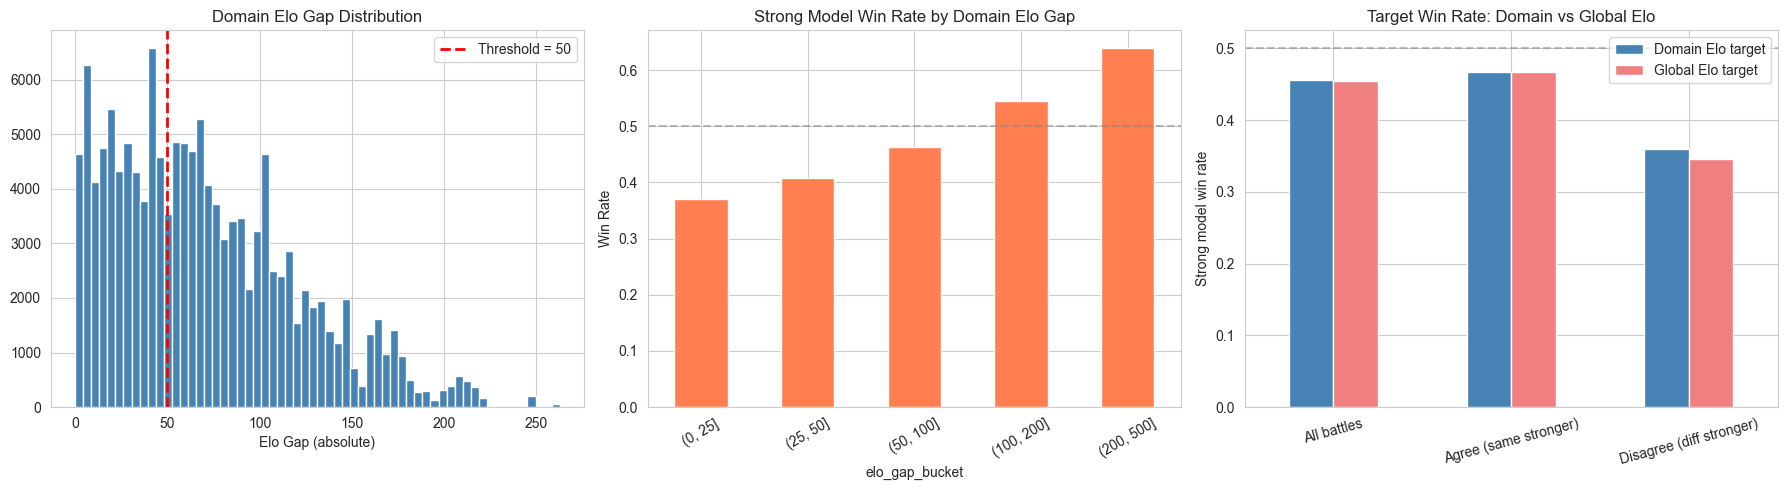


Comparison table:
                          Domain Elo target  Global Elo target
All battles                           0.456              0.455
Agree (same stronger)                 0.467              0.467
Disagree (diff stronger)              0.359              0.346


In [13]:
# Step 2e: Apply minimum Elo gap filter (using DOMAIN Elo gap)

MIN_ELO_GAP = 50

print(f"Domain Elo gap distribution:")
print(df_clean['elo_domain_gap'].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Domain Elo gap distribution
df_clean['elo_domain_gap'].clip(upper=500).hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(MIN_ELO_GAP, color='red', linestyle='--', linewidth=2, label=f'Threshold = {MIN_ELO_GAP}')
axes[0].set_title('Domain Elo Gap Distribution')
axes[0].set_xlabel('Elo Gap (absolute)')
axes[0].legend()

# 2. Win rate by domain elo gap bucket
df_clean['elo_gap_bucket'] = pd.cut(df_clean['elo_domain_gap'], bins=[0, 25, 50, 100, 200, 500, 2000])
win_by_gap = df_clean.groupby('elo_gap_bucket', observed=True)['strong_model_won'].agg(['mean', 'count'])
win_by_gap['mean'].plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Strong Model Win Rate by Domain Elo Gap')
axes[1].set_ylabel('Win Rate')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=30)

# 3. COMPARISON — domain vs global Elo target agreement by gap
# In the disagreement zone, which target is more "correct"?
agree = df_clean[~disagree_mask]
disagree = df_clean[disagree_mask]

comparison_data = pd.DataFrame({
    'Domain Elo target': [
        df_clean['strong_model_won'].mean(),
        agree['strong_model_won'].mean() if len(agree) > 0 else np.nan,
        disagree['strong_model_won'].mean() if len(disagree) > 0 else np.nan,
    ],
    'Global Elo target': [
        df_clean['strong_model_won_global'].mean(),
        agree['strong_model_won_global'].mean() if len(agree) > 0 else np.nan,
        disagree['strong_model_won_global'].mean() if len(disagree) > 0 else np.nan,
    ]
}, index=['All battles', 'Agree (same stronger)', 'Disagree (diff stronger)'])

comparison_data.plot.bar(ax=axes[2], color=['steelblue', 'lightcoral'], edgecolor='white')
axes[2].set_title('Target Win Rate: Domain vs Global Elo')
axes[2].set_ylabel('Strong model win rate')
axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nComparison table:")
print(comparison_data.round(3).to_string())

In [14]:
# Apply the filter using DOMAIN Elo gap
df_filtered = df_clean[df_clean['elo_domain_gap'] >= MIN_ELO_GAP].copy()
print(f"After domain Elo gap >= {MIN_ELO_GAP} filter: {len(df_clean):,} -> {len(df_filtered):,} rows")

print(f"\n--- Final target distribution (domain Elo) ---")
print(df_filtered['strong_model_won'].value_counts())
print(f"\n  Proportions:")
print(df_filtered['strong_model_won'].value_counts(normalize=True).round(3))

print(f"\n--- For comparison: global Elo target ---")
print(df_filtered['strong_model_won_global'].value_counts(normalize=True).round(3))

# Win rate by category — now using domain-aware target
print(f"\n--- Win rate by category (DOMAIN Elo target) ---")
for col in [c for c in df_filtered.columns if c.startswith('cat_')]:
    subset = df_filtered[df_filtered[col] == True]
    if len(subset) > 100:
        rate_domain = subset['strong_model_won'].mean()
        rate_global = subset['strong_model_won_global'].mean()
        diff = rate_domain - rate_global
        print(f"  {col}: domain={rate_domain:.1%}  global={rate_global:.1%}  "
              f"delta={diff:+.1%}  (n={len(subset):,})")

# Win rate by domain bucket
print(f"\n--- Win rate by domain bucket ---")
for bucket in DOMAINS:
    subset = df_filtered[df_filtered['domain_bucket'] == bucket]
    if len(subset) > 100:
        rate = subset['strong_model_won'].mean()
        print(f"  {bucket}: {rate:.1%} of {len(subset):,} battles")

After domain Elo gap >= 50 filter: 135,634 -> 79,902 rows

--- Final target distribution (domain Elo) ---
strong_model_won
1    40167
0    39735
Name: count, dtype: int64

  Proportions:
strong_model_won
1    0.503
0    0.497
Name: proportion, dtype: float64

--- For comparison: global Elo target ---
strong_model_won_global
1    0.502
0    0.498
Name: proportion, dtype: float64

--- Win rate by category (DOMAIN Elo target) ---

--- Win rate by domain bucket ---
  code: 49.2% of 21,813 battles
  chat: 50.7% of 58,089 battles


In [15]:
# Save the processed Arena dataset as a checkpoint
df_filtered.drop(columns=['elo_gap_bucket'], errors='ignore').to_parquet('arena_processed_step2.parquet', index=False)
print(f"Saved checkpoint: arena_processed_step2.parquet ({len(df_filtered):,} rows)")

Saved checkpoint: arena_processed_step2.parquet (79,902 rows)


### Step 2 Findings

**Document your observations here.** Key things to note:
- Do the global Elo rankings look reasonable? Do domain-specific rankings fix the issues you saw (e.g., does Claude 4 Opus rank higher in code/math)?
- How often do domain and global Elo disagree about who's "stronger"? (The disagreement rate tells you how much categorical Elo matters)
- In the battles where they disagree, which target has a higher win rate? (Higher = more predictive = better target)
- What does Kendall's tau between domains tell you? Low tau = models have genuinely different strengths = horizontal routing is real
- Does win rate increase more cleanly with domain Elo gap than global Elo gap?

---
## Step 3: Train the WildChat Prompt Classifier

**Goal:** Train a classifier on WildChat-1M-Tagged (which has Mistral-assigned `category` and `complexity` labels) so we can apply it to Arena prompts to get consistent, fine-grained task descriptors.

**Approach:**
- Start with a fast TF-IDF + Logistic Regression baseline to validate the label space
- Then fine-tune DistilBERT for better quality
- Apply both to Arena data and compare

### 3A: Load and prepare WildChat data

In [16]:
print("Loading WildChat-1M-Tagged dataset...")
wildchat_ds = load_dataset("sh0416/wildchat-1m-tagged", split="train")
print(f"Loaded {len(wildchat_ds):,} rows")
print(f"Columns: {wildchat_ds.column_names}")

Loading WildChat-1M-Tagged dataset...
Loaded 837,989 rows
Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header', 'category', 'complexity', 'length']


In [17]:
# Extract first user message, category, and complexity from each conversation

wc_records = []
for i, row in enumerate(wildchat_ds):
    # Extract first user message
    conversation = row.get('conversation', [])
    first_user_msg = ""
    for turn in conversation:
        if isinstance(turn, dict) and turn.get('role') == 'user':
            content = turn.get('content', '')
            if isinstance(content, str):
                first_user_msg = content
            break
    
    category = row.get('category', '')
    complexity = row.get('complexity', -1)
    length_label = row.get('length', '')
    language = row.get('language', '')
    
    # Only keep rows with non-empty prompt and valid category
    if first_user_msg.strip() and category:
        wc_records.append({
            'prompt': first_user_msg,
            'category': category,
            'complexity': complexity,
            'length_label': length_label,
            'language': language,
        })
    
    if (i + 1) % 200000 == 0:
        print(f"  Processed {i+1:,} rows...")

wc_df = pd.DataFrame(wc_records)
print(f"\nExtracted {len(wc_df):,} rows with valid prompts and categories")

print(f"\n--- Category distribution ---")
print(wc_df['category'].value_counts())

print(f"\n--- Complexity distribution ---")
print(wc_df['complexity'].value_counts().sort_index())

print(f"\n--- Length label distribution ---")
print(wc_df['length_label'].value_counts())

  Processed 200,000 rows...
  Processed 400,000 rows...
  Processed 600,000 rows...
  Processed 800,000 rows...

Extracted 831,237 rows with valid prompts and categories

--- Category distribution ---
category
Creative Writing                       291324
Knowledge and Reasoning                181400
Open Question Answering                 73192
Asking for Advice                       52817
Unknown                                 38423
Inhabiting a Character/Persona          36794
Closed Question Answering               33523
Coding                                  28919
Classification                          28826
Rewriting                               27184
Summarization                           12148
Other                                    9168
Humanity, History or Social Studies      6972
Extraction                               5941
Mathematical reasoning                   3089
Brainstorming                            1517
Name: count, dtype: int64

--- Complexity distribution

In [18]:
# ---- Prepare training data ----
# Sample down to ~150K for manageable training time
# Stratify by category to preserve distribution

SAMPLE_SIZE = 150_000

# Filter to English only for cleaner training (Arena data is ~70% English)
wc_english = wc_df[wc_df['language'] == 'English'].copy()
print(f"English-only: {len(wc_english):,} rows")

# Collapse rare categories (< 1% of data) into 'Other'
cat_counts = wc_english['category'].value_counts()
rare_cats = cat_counts[cat_counts < len(wc_english) * 0.01].index.tolist()
if rare_cats:
    print(f"Collapsing {len(rare_cats)} rare categories into 'Other': {rare_cats}")
    wc_english.loc[wc_english['category'].isin(rare_cats), 'category'] = 'Other'

# Stratified sample
if len(wc_english) > SAMPLE_SIZE:
    wc_sample = wc_english.groupby('category', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), int(SAMPLE_SIZE * len(x) / len(wc_english))),
                           random_state=42)
    ).reset_index(drop=True)
else:
    wc_sample = wc_english.copy()

print(f"Training sample: {len(wc_sample):,} rows")
print(f"\nCategory distribution in sample:")
print(wc_sample['category'].value_counts())

# Create complexity bins for classification (low/medium/high)
# Complexity is on a 1-10 scale from Mistral
def bin_complexity(c):
    if c <= 3:
        return 'low'
    elif c <= 6:
        return 'medium'
    else:
        return 'high'

wc_sample['complexity_bin'] = wc_sample['complexity'].apply(bin_complexity)
print(f"\nComplexity bin distribution:")
print(wc_sample['complexity_bin'].value_counts())

English-only: 477,095 rows
Collapsing 5 rare categories into 'Other': ['Other', 'Extraction', 'Humanity, History or Social Studies', 'Mathematical reasoning', 'Brainstorming']
Training sample: 149,993 rows

Category distribution in sample:


KeyError: 'category'

In [ ]:
# ---- Train/val/test split ----
from sklearn.model_selection import train_test_split

# 80/10/10 split, stratified by category
train_df, temp_df = train_test_split(
    wc_sample, test_size=0.2, random_state=42, stratify=wc_sample['category']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['category']
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

### 3B: Baseline — TF-IDF + Logistic Regression

This gives us a quick sanity check: are the WildChat labels learnable at all? If TF-IDF + LR can't do better than random, the labels are too noisy.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---- Category classifier ----
print("Training TF-IDF + LR baseline for CATEGORY...")

# Truncate prompts to first 512 chars for speed
tfidf_cat = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), max_df=0.95, min_df=5)
X_train_tfidf = tfidf_cat.fit_transform(train_df['prompt'].str[:512])
X_val_tfidf = tfidf_cat.transform(val_df['prompt'].str[:512])
X_test_tfidf = tfidf_cat.transform(test_df['prompt'].str[:512])

lr_cat = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial', n_jobs=-1)
lr_cat.fit(X_train_tfidf, train_df['category'])

# Evaluate on test set
y_pred_cat = lr_cat.predict(X_test_tfidf)
print(f"\n--- Category Classification Report (TF-IDF + LR) ---")
print(f"Accuracy: {accuracy_score(test_df['category'], y_pred_cat):.3f}")
print(classification_report(test_df['category'], y_pred_cat, zero_division=0))

In [ ]:
# ---- Complexity classifier ----
print("Training TF-IDF + LR baseline for COMPLEXITY...")

tfidf_cplx = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), max_df=0.95, min_df=5)
X_train_cplx = tfidf_cplx.fit_transform(train_df['prompt'].str[:512])
X_test_cplx = tfidf_cplx.transform(test_df['prompt'].str[:512])

lr_cplx = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial', n_jobs=-1)
lr_cplx.fit(X_train_cplx, train_df['complexity_bin'])

y_pred_cplx = lr_cplx.predict(X_test_cplx)
print(f"\n--- Complexity Classification Report (TF-IDF + LR) ---")
print(f"Accuracy: {accuracy_score(test_df['complexity_bin'], y_pred_cplx):.3f}")
print(classification_report(test_df['complexity_bin'], y_pred_cplx, zero_division=0))

### 3C: DistilBERT Classifier (Category)

Now we train a DistilBERT classifier for higher quality predictions. This requires a GPU.

**Note:** If running on Colab free tier, you may want to reduce the sample size or number of epochs.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Encode category labels
cat_le = LabelEncoder()
cat_le.fit(wc_sample['category'])
num_categories = len(cat_le.classes_)
print(f"Number of categories: {num_categories}")
print(f"Categories: {list(cat_le.classes_)}")

In [ ]:
# ---- Dataset class ----
class PromptDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Initialize tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_categories
).to(device)

# Create datasets
train_labels_enc = cat_le.transform(train_df['category'])
val_labels_enc = cat_le.transform(val_df['category'])
test_labels_enc = cat_le.transform(test_df['category'])

train_dataset = PromptDataset(train_df['prompt'], pd.Series(train_labels_enc), tokenizer)
val_dataset = PromptDataset(val_df['prompt'], pd.Series(val_labels_enc), tokenizer)
test_dataset = PromptDataset(test_df['prompt'], pd.Series(test_labels_enc), tokenizer)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

In [ ]:
# ---- Training loop ----
NUM_EPOCHS = 3  # DistilBERT converges fast; 2-3 epochs is usually enough
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

best_val_acc = 0.0
patience_counter = 0
PATIENCE = 2

history = {'train_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    # ---- Train ----
    model.train()
    total_loss = 0
    for batch_i, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        
        if (batch_i + 1) % 200 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_loss)
    
    # ---- Validate ----
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += len(labels)
    
    val_acc = correct / total
    history['val_acc'].append(val_acc)
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_category_model.pt')
        print(f"  -> New best! Saved model.")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

In [ ]:
# ---- Evaluate on test set ----
model.load_state_dict(torch.load('best_category_model.pt'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Decode labels
pred_cats = cat_le.inverse_transform(all_preds)
true_cats = cat_le.inverse_transform(all_labels)

print("=" * 60)
print("DISTILBERT CATEGORY CLASSIFIER — TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy: {accuracy_score(true_cats, pred_cats):.4f}")
print(f"\n{classification_report(true_cats, pred_cats, zero_division=0)}")

In [ ]:
# ---- Compare TF-IDF vs DistilBERT ----
from sklearn.metrics import f1_score

tfidf_acc = accuracy_score(test_df['category'], y_pred_cat)
tfidf_f1 = f1_score(test_df['category'], y_pred_cat, average='macro', zero_division=0)

bert_acc = accuracy_score(true_cats, pred_cats)
bert_f1 = f1_score(true_cats, pred_cats, average='macro', zero_division=0)

print(f"\n--- Classifier Comparison ---")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'TF-IDF + LR':<25} {tfidf_acc:>10.4f} {tfidf_f1:>10.4f}")
print(f"{'DistilBERT':<25} {bert_acc:>10.4f} {bert_f1:>10.4f}")
print(f"\nDelta: +{bert_acc - tfidf_acc:.4f} accuracy, +{bert_f1 - tfidf_f1:.4f} macro F1")

### 3D: Apply the classifier to Arena prompts

Use whichever classifier performed better (likely DistilBERT) to label all Arena prompts with predicted category and complexity.

In [ ]:
# ---- Apply DistilBERT category classifier to Arena data ----

def predict_categories_batch(texts, model, tokenizer, cat_le, device, batch_size=64):
    """Predict categories for a list of texts using the trained DistilBERT model."""
    model.eval()
    all_preds = []
    all_probs = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        encoding = tokenizer(
            batch_texts,
            truncation=True,
            max_length=256,
            padding=True,
            return_tensors='pt'
        )
        
        with torch.no_grad():
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = probs.argmax(dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.max(dim=-1).values.cpu().numpy())
        
        if (i + batch_size) % 5000 < batch_size:
            print(f"  Predicted {min(i + batch_size, len(texts)):,} / {len(texts):,}")
    
    return cat_le.inverse_transform(all_preds), np.array(all_probs)


# Prepare Arena prompts
arena_prompts = df_filtered['prompt_text'].fillna('').tolist()
print(f"Predicting categories for {len(arena_prompts):,} Arena prompts...")

pred_categories, pred_confidences = predict_categories_batch(
    arena_prompts, model, tokenizer, cat_le, device
)

df_filtered['predicted_category'] = pred_categories
df_filtered['category_confidence'] = pred_confidences

print(f"\n--- Predicted category distribution on Arena data ---")
print(df_filtered['predicted_category'].value_counts())
print(f"\nMean confidence: {pred_confidences.mean():.3f}")
print(f"Median confidence: {np.median(pred_confidences):.3f}")

In [ ]:
# ---- Apply TF-IDF complexity classifier to Arena data ----
# (Using TF-IDF for complexity since it's a coarser signal and LR is faster)

X_arena_cplx = tfidf_cplx.transform(df_filtered['prompt_text'].fillna('').str[:512])
df_filtered['predicted_complexity'] = lr_cplx.predict(X_arena_cplx)

print(f"--- Predicted complexity distribution on Arena data ---")
print(df_filtered['predicted_complexity'].value_counts())

In [ ]:
# ---- Cross-check: predicted labels vs existing Arena category tags ----
# This validates that our classifier produces sensible labels on Arena data

print("--- Cross-validation: predicted category vs Arena category tags ---\n")

for tag_col in [c for c in df_filtered.columns if c.startswith('cat_')]:
    tag_name = tag_col.replace('cat_', '')
    tagged_rows = df_filtered[df_filtered[tag_col] == True]
    if len(tagged_rows) > 100:
        top_pred = tagged_rows['predicted_category'].value_counts(normalize=True).head(3)
        print(f"Arena tag '{tag_name}' ({len(tagged_rows):,} rows) -> Top predicted categories:")
        for cat, pct in top_pred.items():
            print(f"    {cat}: {pct:.1%}")
        print()

In [ ]:
# ---- Win rate analysis by predicted category and complexity ----
print("--- Strong model win rate by PREDICTED CATEGORY ---")
cat_win_rates = (
    df_filtered.groupby('predicted_category')['strong_model_won']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
cat_win_rates.columns = ['win_rate', 'n_battles']
print(cat_win_rates.to_string())

print("\n--- Strong model win rate by PREDICTED COMPLEXITY ---")
cplx_win_rates = (
    df_filtered.groupby('predicted_complexity')['strong_model_won']
    .agg(['mean', 'count'])
)
cplx_win_rates.columns = ['win_rate', 'n_battles']
print(cplx_win_rates.to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cat_win_rates['win_rate'].plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Strong Model Win Rate by Predicted Category')
axes[0].set_xlabel('Win Rate')

order = ['low', 'medium', 'high']
cplx_ordered = cplx_win_rates.reindex(order)
cplx_ordered['win_rate'].plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Strong Model Win Rate by Predicted Complexity')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# ---- Save the enriched dataset ----
output_cols = [
    'id', 'model_a', 'model_b', 'winner', 'language', 'is_code',
    'prompt_text', 'num_turns_a', 'num_turns_b',
    'cat_math', 'cat_coding', 'cat_creative_writing',
    'cat_instruction_following', 'cat_hard_prompt',
    'domain_bucket',
    # Global Elo
    'elo_global_a', 'elo_global_b', 'elo_global_gap',
    # Domain Elo
    'elo_domain_a', 'elo_domain_b', 'elo_domain_gap',
    # Target variables (both, for comparison)
    'stronger_model_name', 'weaker_model_name',
    'strong_model_won',          # PRIMARY (domain Elo)
    'strong_model_won_global',   # COMPARISON (global Elo)
    # WildChat-derived (added in Step 3)
    'predicted_category', 'category_confidence', 'predicted_complexity',
    'prompt_word_count',
]
# Only include columns that exist
output_cols = [c for c in output_cols if c in df_filtered.columns]

df_filtered[output_cols].to_parquet('arena_enriched_phase1.parquet', index=False)
print(f"Saved: arena_enriched_phase1.parquet")
print(f"Shape: {df_filtered[output_cols].shape}")
print(f"Columns: {output_cols}")

---
## Phase 1 Summary & Next Steps

### What we built:
1. **Loaded and audited** the Arena 140K dataset — confirmed structure, identified winner distribution, model coverage, and category tag sparsity.
2. **Constructed the target variable** (`strong_model_won`) by computing Elo ratings from battle data and filtering to meaningful Elo gaps (≥50 points).
3. **Trained a prompt classifier** on WildChat-1M-Tagged data (both TF-IDF baseline and DistilBERT), then applied it to Arena prompts to add `predicted_category` and `predicted_complexity` features.

### Key deliverable:
`arena_enriched_phase1.parquet` — the Arena dataset with target variable, Elo ratings, and WildChat-derived features attached.

### What comes next (Phase 2):
- **Tier 2 feature extraction** (constraint count, readability, keyword detection, etc.)
- **Tier 3 features** (sentence-transformer embeddings, response divergence)
- **Full EDA** on the enriched dataset
- **XGBoost and DistilBERT routing models** (the main classifiers)
- **Evaluation** with cost-performance curves